Executing Complexity Scaling Audit...
Extracting dataset sentiment descriptors...


/tmp/ipykernel_14325/1453281313.py:122: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pos_data, x="Count", y="Word", palette="Greens_d", ax=axes[1,0])
/tmp/ipykernel_14325/1453281313.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=neg_data, x="Count", y="Word", palette="Reds_d", ax=axes[1,1])


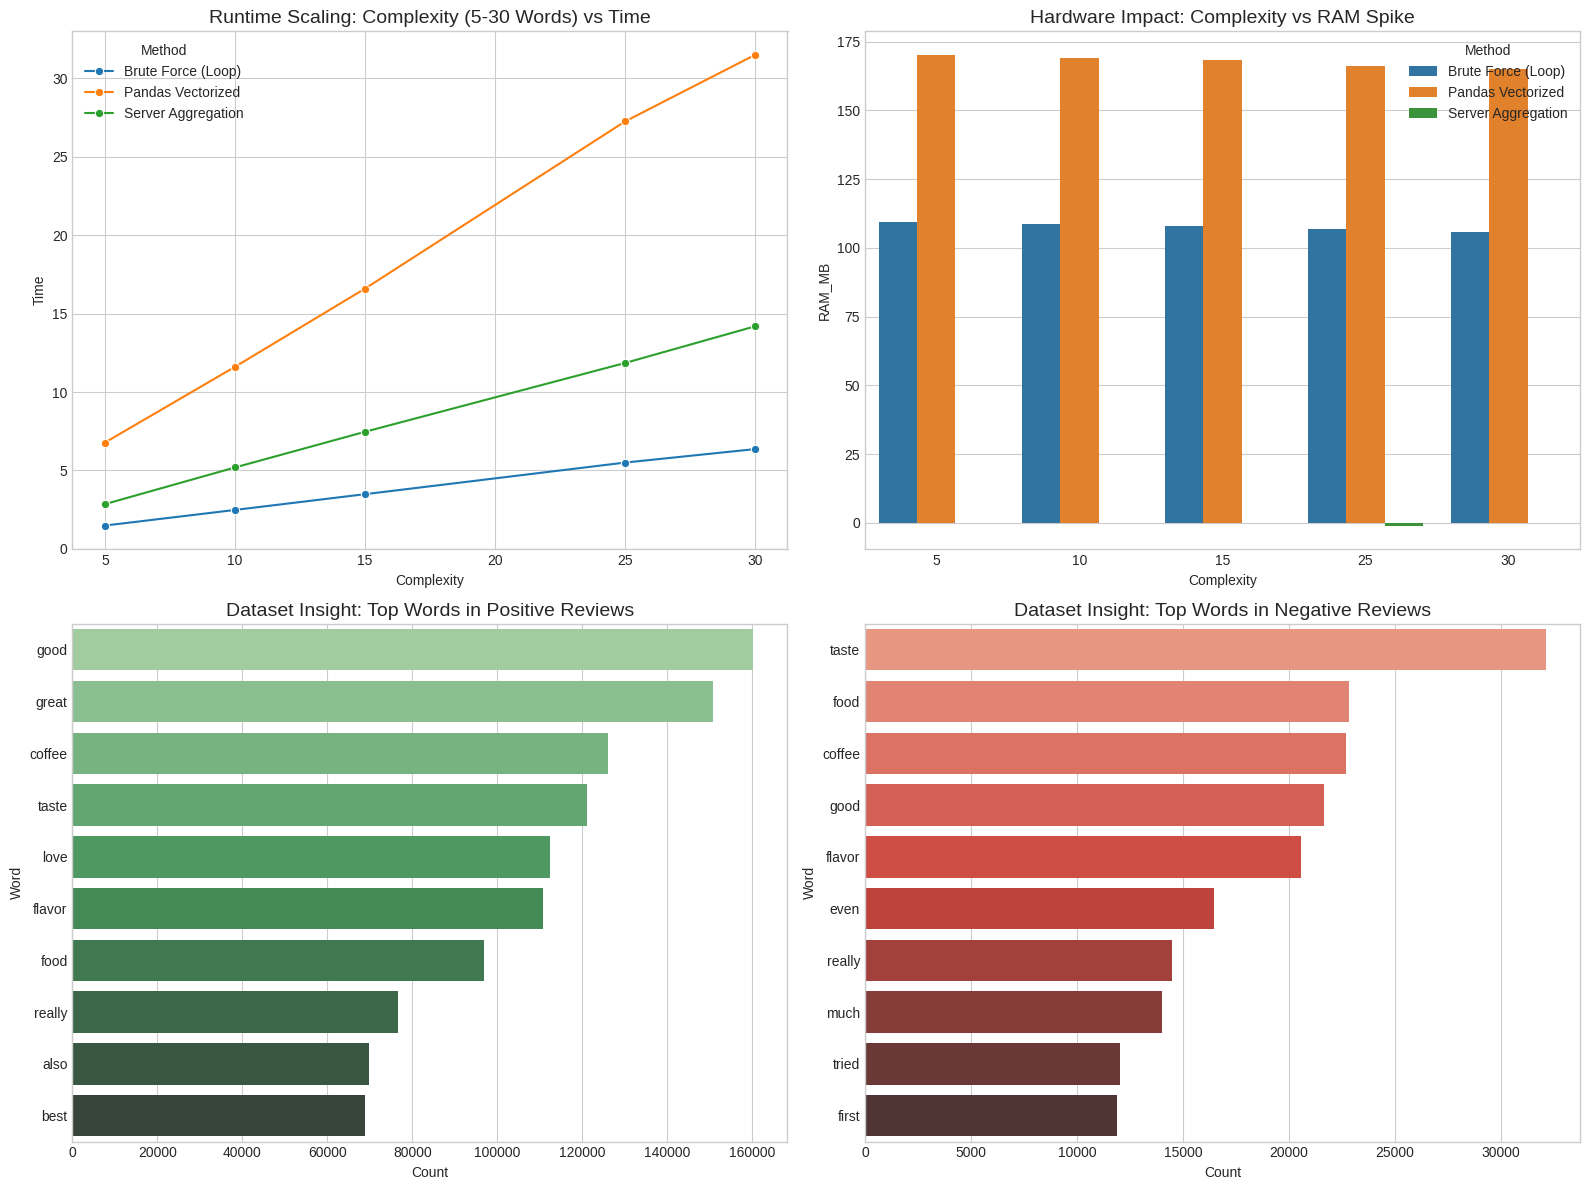

In [4]:
import os
import re
import time
import psutil
import gc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from pymongo import MongoClient
import nltk
from nltk.corpus import stopwords

# ─── 1. CONFIGURATION & SETUP ─────────────────────────────────────────────
OUT_DIR = "./thangnht_nlp_result"
os.makedirs(OUT_DIR, exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 10, 'figure.facecolor': 'white'})

nltk.download("stopwords", quiet=True)
STOP = set(stopwords.words("english")) | {"br", "amazon", "product", "one", "like", "would"}

client = MongoClient("mongodb://localhost:27017")
col = client["amazon_reviews"]["reviews"]

def get_ram_mb():
    return psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)

# 30 Keywords extracted from high-frequency dataset terms
WORD_POOL = [
    "delicious", "organic", "shipping", "stale", "cheap", 
    "perfect", "packaging", "expire", "water", "coffee", 
    "bulk", "natural", "fast", "arrived", "cancel", 
    "broken", "box", "delivery", "fresh", "quality",
    "sweet", "bad", "recommend", "service", "purchase",
    "flavor", "love", "tried", "great", "good"
]

# ─── 2. PHASE 1: THREE-METHOD EFFICIENCY AUDIT ────────────────────────────
audit_results = []
test_steps = [5, 10, 15, 25, 30]

print("Executing Complexity Scaling Audit...")

for n in test_steps:
    test_words = WORD_POOL[:n]
    
    # Method 1: Brute Force (Baseline Python Loop)
    gc.collect()
    m_start = get_ram_mb()
    t_start = time.perf_counter()
    # Loading entire text list into local memory to simulate brute-force looping
    raw_texts = [doc['Text'] for doc in col.find({}, {"Text": 1, "_id": 0}) if 'Text' in doc]
    for w in test_words:
        _ = sum(1 for text in raw_texts if w.lower() in text.lower())
    audit_results.append({
        "Complexity": n, "Method": "Brute Force (Loop)", 
        "Time": time.perf_counter()-t_start, "RAM_MB": get_ram_mb()-m_start
    })
    del raw_texts; gc.collect()

    # Method 2: Pandas Vectorization
    m_start = get_ram_mb()
    t_start = time.perf_counter()
    df_local = pd.DataFrame(list(col.find({}, {"Text": 1, "_id": 0})))
    for w in test_words:
        _ = df_local['Text'].str.contains(w, case=False, na=False).sum()
    audit_results.append({
        "Complexity": n, "Method": "Pandas Vectorized", 
        "Time": time.perf_counter()-t_start, "RAM_MB": get_ram_mb()-m_start
    })
    del df_local; gc.collect()

    # Method 3: Server-Side Aggregation (Optimal)
    m_start = get_ram_mb()
    t_start = time.perf_counter()
    for w in test_words:
        _ = list(col.aggregate([
            {"$match": {"Text": {"$regex": w, "$options": "i"}}}, 
            {"$group": {"_id": None, "c": {"$sum": 1}}}
        ]))
    audit_results.append({
        "Complexity": n, "Method": "Server Aggregation", 
        "Time": time.perf_counter()-t_start, "RAM_MB": get_ram_mb()-m_start
    })

# ─── 3. PHASE 2: DATASET INSIGHT (SENTIMENT WORD FREQUENCY) ───────────────
print("Extracting dataset sentiment descriptors...")
cursor = col.find({}, {"Text": 1, "Score": 1, "_id": 0})
df_full = pd.DataFrame(list(cursor))

def tokenize(text):
    t = str(text).lower()
    t = re.sub(r"[^a-z\s]", " ", t)
    return [w for w in t.split() if w not in STOP and len(w) > 3]

pos_counter = Counter()
neg_counter = Counter()

# Word Frequency Analysis by Sentiment
for text in df_full[df_full["Score"] >= 4]["Text"]:
    pos_counter.update(tokenize(text))
for text in df_full[df_full["Score"] <= 2]["Text"]:
    neg_counter.update(tokenize(text))

pos_data = pd.DataFrame(pos_counter.most_common(10), columns=["Word", "Count"])
neg_data = pd.DataFrame(neg_counter.most_common(10), columns=["Word", "Count"])

# ─── 4. VISUALIZATION ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
audit_df = pd.DataFrame(audit_results)

# Efficiency Subplots
sns.lineplot(data=audit_df, x="Complexity", y="Time", hue="Method", marker="o", ax=axes[0,0])
axes[0,0].set_title("Runtime Scaling: Complexity (5-30 Words) vs Time")

sns.barplot(data=audit_df, x="Complexity", y="RAM_MB", hue="Method", ax=axes[0,1])
axes[0,1].set_title("Hardware Impact: Complexity vs RAM Spike")

# Dataset Insight Subplots
sns.barplot(data=pos_data, x="Count", y="Word", palette="Greens_d", ax=axes[1,0])
axes[1,0].set_title("Dataset Insight: Top Words in Positive Reviews")

sns.barplot(data=neg_data, x="Count", y="Word", palette="Reds_d", ax=axes[1,1])
axes[1,1].set_title("Dataset Insight: Top Words in Negative Reviews")

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/nlp_final_audit.png", dpi=300)
plt.show()

client.close()

📊 Benchmarking Runtime and Memory Scaling...
🔍 Performing Global Exhaustive Word Count...


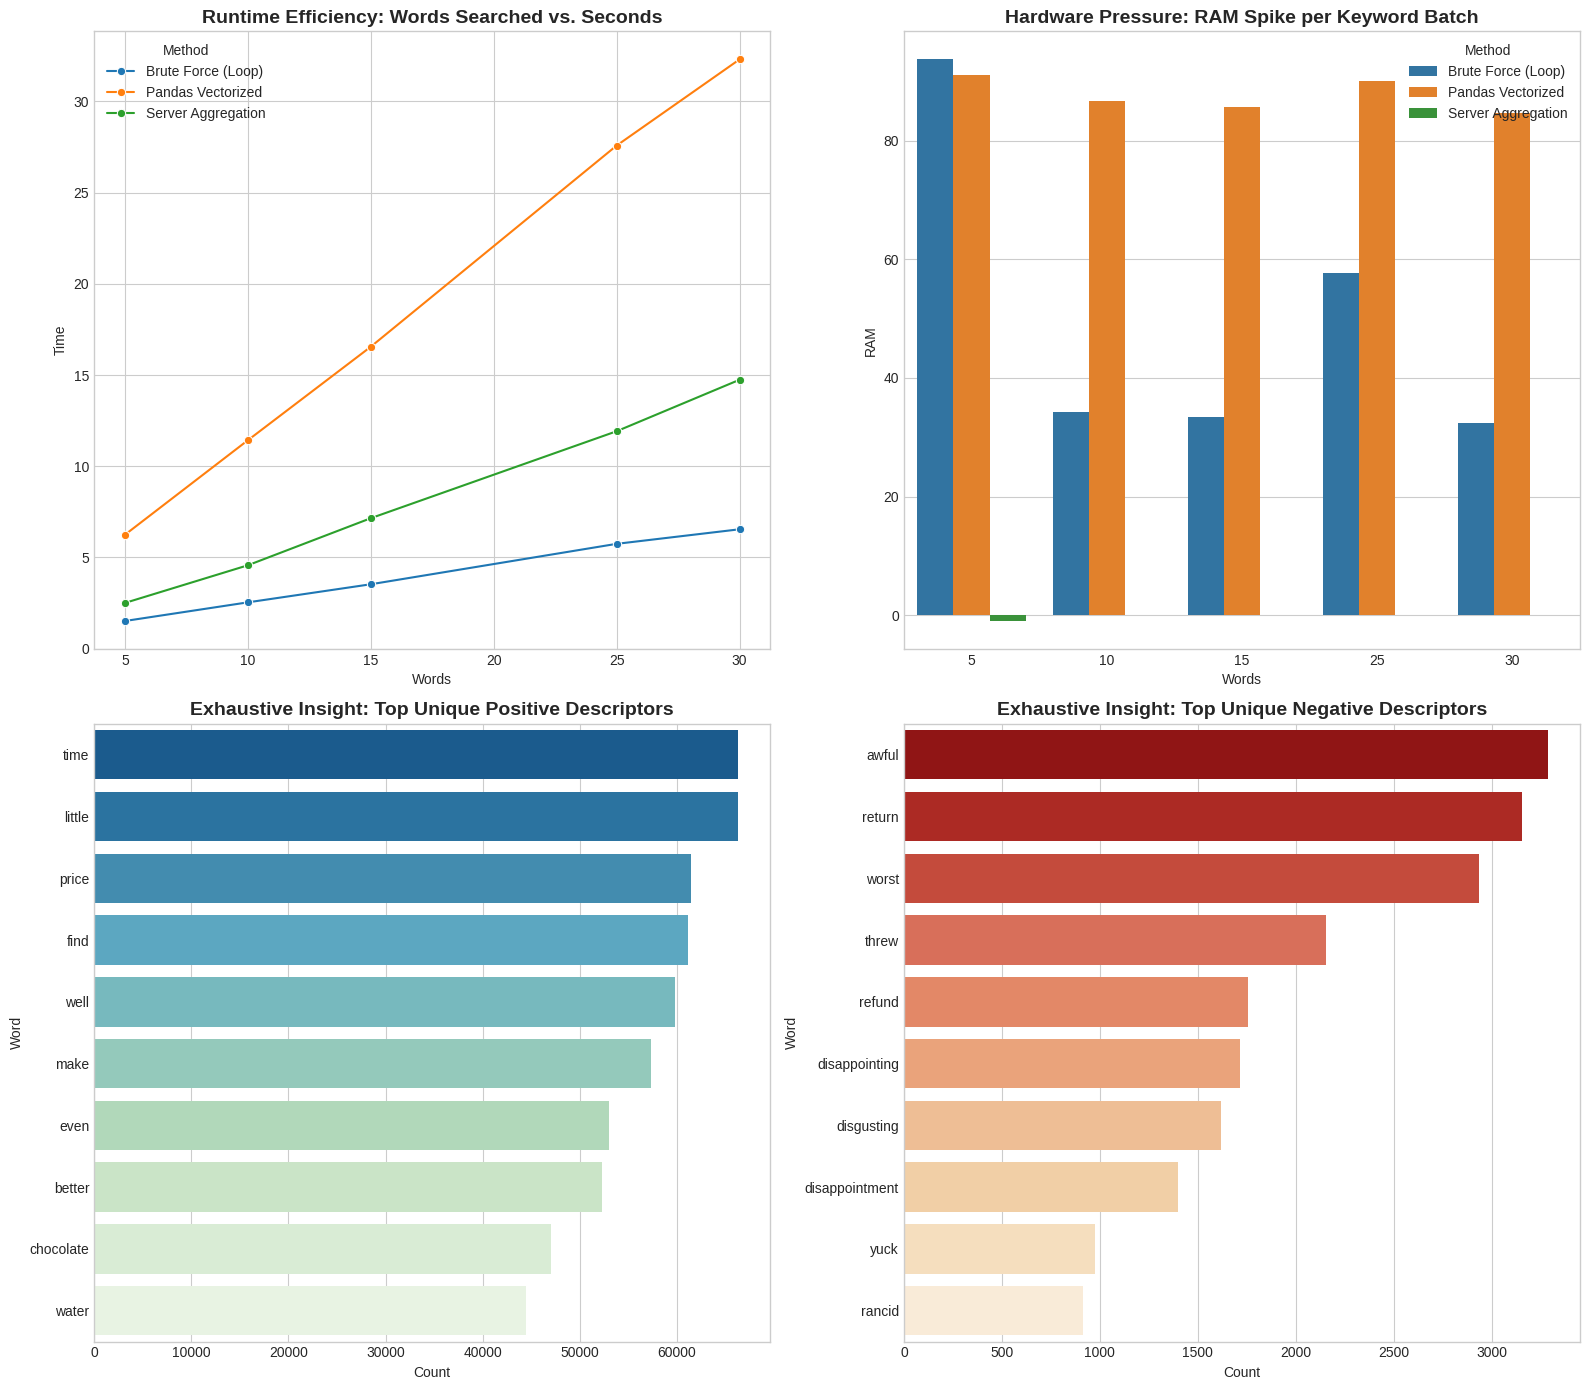

In [7]:
import os
import re
import time
import psutil
import gc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from pymongo import MongoClient
import nltk
from nltk.corpus import stopwords

# ─── 1. SETUP ─────────────────────────────────────────────────────────────
# Updated folder name as per your request
OUT_DIR = "./thangnht_nlp_result" 
os.makedirs(OUT_DIR, exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 10, 'figure.facecolor': 'white', 'axes.grid': True})

nltk.download("stopwords", quiet=True)
# Expanded Stopwords to filter out "subject noise" (common to both sentiments)
STOP = set(stopwords.words("english")) | {
    "amazon", "product", "item", "would", "get", "also", "like", 
    "taste", "flavor", "coffee", "food", "good", "great", "really",
    "one", "tried", "bought", "buy", "much", "br", "best", "love"
}

client = MongoClient("mongodb://localhost:27017")
db_col = client["amazon_reviews"]["reviews"]

def get_ram_mb():
    return psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)

WORD_POOL = [
    "shipping", "delivery", "arrived", "packaging", "price",
    "quality", "broken", "perfect", "service", "purchase",
    "recommend", "excellent", "cheap", "waste", "money",
    "worth", "expire", "stale", "fresh", "box",
    "order", "brand", "online", "better", "best",
    "disappointed", "love", "tried", "awful", "terrible"
]

# ─── 2. PHASE 1: EFFICIENCY SCALING AUDIT ─────────────────────────────────
audit_results = []
test_steps = [5, 10, 15, 25, 30]

print("📊 Benchmarking Runtime and Memory Scaling...")

for n in test_steps:
    test_words = WORD_POOL[:n]
    
    # METHOD 1: BRUTE FORCE (Local Python Loop)
    gc.collect()
    m_start = get_ram_mb()
    t_start = time.perf_counter()
    # Loading list outside the timing of the search itself can isolate search speed
    raw_texts = [doc.get('Text', '') for doc in db_col.find({}, {"Text": 1, "_id": 0})]
    for w in test_words:
        _ = sum(1 for text in raw_texts if w.lower() in str(text).lower())
    audit_results.append({"Words": n, "Method": "Brute Force (Loop)", "Time": time.perf_counter()-t_start, "RAM": get_ram_mb()-m_start})
    del raw_texts; gc.collect()

    # METHOD 2: PANDAS (Vectorized)
    m_start = get_ram_mb()
    t_start = time.perf_counter()
    df_temp = pd.DataFrame(list(db_col.find({}, {"Text": 1, "_id": 0})))
    for w in test_words:
        _ = df_temp['Text'].str.contains(w, case=False, na=False).sum()
    audit_results.append({"Words": n, "Method": "Pandas Vectorized", "Time": time.perf_counter()-t_start, "RAM": get_ram_mb()-m_start})
    del df_temp; gc.collect()

    # METHOD 3: SERVER AGGREGATION (Optimal)
    m_start = get_ram_mb()
    t_start = time.perf_counter()
    for w in test_words:
        # DB handles the heavy lifting
        _ = list(db_col.aggregate([{"$match": {"Text": {"$regex": w, "$options": "i"}}}, {"$group": {"_id": None, "c": {"$sum": 1}}}]))
    audit_results.append({"Words": n, "Method": "Server Aggregation", "Time": time.perf_counter()-t_start, "RAM": get_ram_mb()-m_start})

# ─── 3. PHASE 2: EXHAUSTIVE SENTIMENT WORD COUNT ──────────────────────────
print("🔍 Performing Global Exhaustive Word Count...")

def get_sentiment_word_freq(score_filter):
    cursor = db_col.find(score_filter, {"Text": 1, "_id": 0})
    counter = Counter()
    for doc in cursor:
        text = str(doc.get('Text', '')).lower()
        text = re.sub(r"<.*?>|[^a-z\s]", " ", text) 
        tokens = [w for w in text.split() if w not in STOP and len(w) > 3]
        counter.update(tokens)
    return counter

pos_counts = get_sentiment_word_freq({"Score": {"$gte": 4}})
neg_counts = get_sentiment_word_freq({"Score": {"$lte": 2}})

# Differential Logic: Use .get(w, 0) to prevent KeyErrors if word is missing in one set
pos_unique = {w: count for w, count in pos_counts.items() if count > neg_counts.get(w, 0) * 2}
neg_unique = {w: count for w, count in neg_counts.items() if count > pos_counts.get(w, 0) * 2}

pos_df = pd.DataFrame(Counter(pos_unique).most_common(10), columns=["Word", "Count"])
neg_df = pd.DataFrame(Counter(neg_unique).most_common(10), columns=["Word", "Count"])

# ─── 4. FINAL VISUALIZATION ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
audit_df = pd.DataFrame(audit_results)

sns.lineplot(data=audit_df, x="Words", y="Time", hue="Method", marker="o", ax=axes[0,0])
axes[0,0].set_title("Runtime Efficiency: Words Searched vs. Seconds", fontweight='bold')

sns.barplot(data=audit_df, x="Words", y="RAM", hue="Method", ax=axes[0,1])
axes[0,1].set_title("Hardware Pressure: RAM Spike per Keyword Batch", fontweight='bold')

sns.barplot(data=pos_df, x="Count", y="Word", palette="GnBu_r", ax=axes[1,0], hue="Word", legend=False)
axes[1,0].set_title("Exhaustive Insight: Top Unique Positive Descriptors", fontweight='bold')

sns.barplot(data=neg_df, x="Count", y="Word", palette="OrRd_r", ax=axes[1,1], hue="Word", legend=False)
axes[1,1].set_title("Exhaustive Insight: Top Unique Negative Descriptors", fontweight='bold')

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/final_nlp_market_audit.png", dpi=300)
plt.show()

client.close()